# 📌 Project Summary

This project Analysis and Predict Rating for a home-services platform.  
It simulates interactions between **technicians** and **customers**, including service types, job conditions, ratings, and final satisfaction scores.  
The Data set is designed for **data analysis**, **machine learning experiments**, and **dashboard development**.

---

# 📊 Column Descriptions

| Column Name        | Description                                                                 |
|--------------------|-----------------------------------------------------------------------------|
| CustomerID         | Unique ID identifying the customer                                          |
| TechnicianID       | Unique ID identifying the technician                                        |
| UserAvgRating      | Average rating given by the customer across all previous jobs               |
| WorkerAvgRating    | Average rating received by the technician from all customers                |
| UserRatingStd      | Standard deviation of customer's rating behavior                            |
| UserWorkerAvg      | Average rating this customer has given specifically to this technician      |
| FeedbackCount      | Number of feedback entries this customer has submitted                      |
| WorkerRatingVar    | Rating variance for the technician across all customers                     |
| predictedRating      | Rating given for the current job                                          |
| RatingDeviation    | Difference between current rating and customer's historical average rating (predictedRating - UserAvgRating) |
| IsAnomalous        | Flag (0/1) showing whether the rating is anomalous    

<hr style="border: 2px solid red; width: 80%;">
<h1 style="text-align:center; font-family: 'Arial', sans-serif; color : black;">
1-Imports & Reading Data
</h1>
<hr style="border: 2px solid red; width: 80%;">

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# import plotly.express as px
# %matplotlib inline

# from sklearn.preprocessing import StandardScaler , RobustScaler
# from sklearn.model_selection import train_test_split ,GridSearchCV ,learning_curve
# from sklearn.preprocessing import OrdinalEncoder ,OneHotEncoder

# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier ,ExtraTreesClassifier 
# from sklearn.svm import SVC
# from lightgbm import LGBMClassifier
# from xgboost import XGBClassifier
# from catboost import CatBoostClassifier
# from imblearn.under_sampling import RandomUnderSampler
# from sklearn.ensemble import VotingClassifier

# from sklearn.model_selection import KFold , StratifiedKFold
# from sklearn.pipeline import Pipeline

# from sklearn.metrics import (
#     accuracy_score, precision_score, recall_score, f1_score,classification_report,
#     confusion_matrix, ConfusionMatrixDisplay,
#     roc_auc_score, RocCurveDisplay,
#     precision_recall_curve, average_precision_score
# )



# import warnings
# warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv(r'D:\Fixy\AI Implementation\Anomly_Detection\datasets\Anomaly_Detection_Dataset_v7_1.csv')
df.tail(15)   

,CustomerID,TechnicianID,UserAvgRating,WorkerAvgRating,UserRatingStd,UserWorkerAvg,FeedbackCount,WorkerRatingVar,RatingDeviation,predictedRating,IsAnomalous
399985,48562,3197,3.263140,4.147860,0.561761,3.292346,7.0,0.322679,-0.115247,3.555557,1
399986,65547,3050,3.609093,3.810318,0.101429,3.244949,6.0,0.266372,-0.306095,3.416785,0
399987,13211,2592,3.681991,4.271338,0.503541,3.701284,3.0,0.175289,-0.061208,3.922314,0
399988,64293,6088,3.201542,4.027680,0.858052,3.146828,5.0,0.272447,-1.547177,2.835006,1
399989,64376,7758,3.811168,3.901133,0.374142,3.334584,8.0,0.136695,0.113947,3.924327,0
399990,43976,5392,3.780868,3.959205,0.558139,2.869485,6.0,0.086728,-0.088495,3.520702,1
399991,3869,4325,4.330055,4.893534,0.350826,3.738968,7.0,0.050000,0.010084,4.456324,0
399992,43884,4518,2.495542,3.709943,0.507669,2.401843,4.0,0.245171,0.210995,3.175038,1
399993,35795,3998,3.917286,4.267497,NaN,3.697256,8.0,0.099537,-0.057302,4.230939,0
399994,54286,8676,4.131352,3.861291,0.557024,3.274338,5.0,0.050000,0.017552,3.617622,1


In [3]:
df.shape

(400000, 11)

<hr style="border: 2px solid red; width: 80%;">
<h1 style="text-align:center; font-family: 'Arial', sans-serif; color : black;">
2 - Exploratory Data Analysis (EDA) & Feature Engineering
</h1>
<hr style="border: 2px solid red; width: 80%;">

In [4]:

df['IsAnomalous'].value_counts()

IsAnomalous
0    228000
1    172000
Name: count, dtype: int64

In [5]:
df.describe()

,CustomerID,TechnicianID,UserAvgRating,WorkerAvgRating,UserRatingStd,UserWorkerAvg,FeedbackCount,WorkerRatingVar,RatingDeviation,predictedRating,IsAnomalous
count,400000.000000,400000.000000,397643.000000,398700.000000,393334.000000,392914.000000,396165.000000,394615.000000,396526.000000,400000.000000,400000.000000
mean,34999.554978,5005.465300,3.598838,4.096307,0.461726,3.323938,6.997483,0.141013,0.001389,3.744007,0.430000
std,20226.425246,2884.849514,0.398409,0.341983,0.168415,0.313623,2.449574,0.087930,0.602706,0.434282,0.495076
min,1.000000,1.000000,2.033307,2.734945,0.100039,1.869004,1.000000,0.050000,-3.500000,1.000000,0.000000
25%,17485.000000,2507.000000,3.330435,3.860462,0.339795,3.112626,5.000000,0.050000,-0.056617,3.534649,0.000000
50%,35015.000000,5004.000000,3.597907,4.097663,0.457217,3.325046,7.000000,0.124768,0.000441,3.756911,0.000000
75%,52569.000000,7503.000000,3.867365,4.333447,0.576154,3.535890,9.000000,0.200138,0.057219,3.976181,1.000000
max,70000.000000,10000.000000,4.995522,4.998337,1.184525,4.864706,19.000000,0.515004,3.500000,5.000000,1.000000


# Data Types

In [6]:
df.dtypes


CustomerID           int64
TechnicianID         int64
UserAvgRating      float64
WorkerAvgRating    float64
UserRatingStd      float64
UserWorkerAvg      float64
FeedbackCount      float64
WorkerRatingVar    float64
RatingDeviation    float64
predictedRating    float64
IsAnomalous          int64
dtype: object

# Unique Values

In [7]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print('-------------------')

CustomerID
[15796   861 54887 ...  4089 44921 29756]
-------------------
TechnicianID
[4729 6102  409 ... 9455 4459 1139]
-------------------
UserAvgRating
[4.00542433 3.86960144 3.75705399 ... 3.16292399 4.68041267 3.36869559]
-------------------
WorkerAvgRating
[       nan 4.23889326 3.88859026 ... 3.82045907 4.42060738 4.40388757]
-------------------
UserRatingStd
[0.24470382 0.42014779 0.64214244 ... 0.15028759 0.56339725 0.76468438]
-------------------
UserWorkerAvg
[3.66047557 3.18060674 3.17579062 ... 3.43207003 3.55278155 3.29446164]
-------------------
FeedbackCount
[ 5.  7.  4.  8. 10. nan 11.  9.  6.  3. 12. 14.  2.  1. 13. 17. 15. 16.
 18. 19.]
-------------------
WorkerRatingVar
[0.06755115 0.08737991 0.15637659 ... 0.24092202 0.24363646 0.17363759]
-------------------
RatingDeviation
[-0.03238333 -0.03940109  0.10730643 ... -0.05041789  0.25750214
 -0.01822596]
-------------------
predictedRating
[4.18087894 3.78828553 3.72605878 ... 3.71320849 3.79574997 3.83850029]
----

# Duplicated Data

In [8]:
df.duplicated().sum()

np.int64(0)

# Missing Data

In [9]:
df.isna().sum().sort_values(ascending=False)

UserWorkerAvg      7086
UserRatingStd      6666
WorkerRatingVar    5385
FeedbackCount      3835
RatingDeviation    3474
UserAvgRating      2357
WorkerAvgRating    1300
TechnicianID          0
CustomerID            0
predictedRating       0
IsAnomalous           0
dtype: int64

#### Check If All Null Lie In The Same Row

In [10]:
df[df['FeedbackCount'].isna()]

,CustomerID,TechnicianID,UserAvgRating,WorkerAvgRating,UserRatingStd,UserWorkerAvg,FeedbackCount,WorkerRatingVar,RatingDeviation,predictedRating,IsAnomalous
7,16024,1691,4.025220,3.853423,0.238487,3.720874,NaN,0.245812,0.014015,3.890578,0
43,69480,3643,3.447107,3.948371,0.591444,2.839010,NaN,0.050000,-0.009612,3.459964,0
220,61136,4683,3.439969,3.747841,0.470877,2.856019,NaN,NaN,-0.033843,3.640902,0
444,1063,7051,4.564098,3.702708,0.262814,3.551784,NaN,0.186900,0.353154,4.140268,0
459,39082,2391,3.651060,4.591071,0.599882,3.361386,NaN,0.089969,-0.046446,4.257961,1
...,...,...,...,...,...,...,...,...,...,...,...
399256,29691,9693,3.471886,4.079156,NaN,3.232619,NaN,0.050000,-0.039138,3.856166,1
399302,5743,2152,3.623258,4.845412,0.530115,3.668918,NaN,0.050000,0.056361,4.237849,1
399591,45391,780,3.814252,3.797770,0.403854,3.314668,NaN,0.201583,0.235273,3.618319,0
399882,20350,5049,3.801439,3.813524,0.775538,3.267172,NaN,0.310158,0.915610,4.218905,1


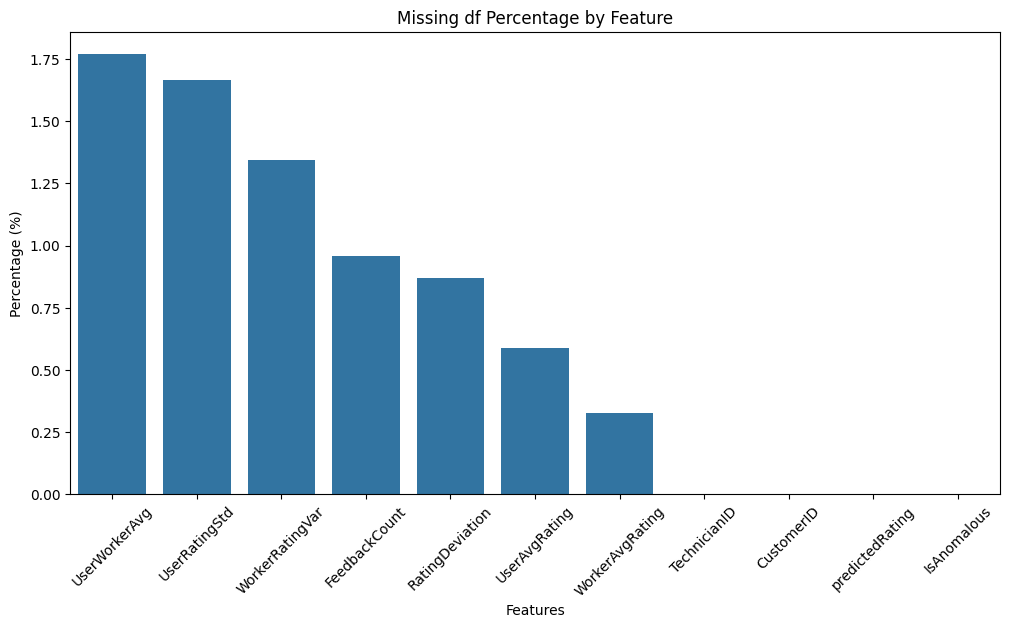

In [11]:
missing_percentage = df.isna().sum() / len(df) * 100
missing_percentage = missing_percentage.to_frame(name='Missing Percentage').sort_values(
    by='Missing Percentage', ascending=False
)

plt.figure(figsize=(12, 6))  
sns.barplot(x=missing_percentage.index, y='Missing Percentage', data=missing_percentage)
plt.xticks(rotation=45)
plt.title("Missing df Percentage by Feature")
plt.xlabel("Features")
plt.ylabel("Percentage (%)")
plt.show()


In [12]:
df.dropna(inplace=True)

In [13]:
df['IsAnomalous'].value_counts()

IsAnomalous
0    211448
1    159364
Name: count, dtype: int64

## Feature Engineering

In [14]:
df['predictedRating'] = round(df['predictedRating']).astype('int64')

In [15]:
df['predictedRating'].value_counts()

predictedRating
4    277844
3     75498
5     11509
2      5200
1       761
Name: count, dtype: int64

In [16]:
df.head()

,CustomerID,TechnicianID,UserAvgRating,WorkerAvgRating,UserRatingStd,UserWorkerAvg,FeedbackCount,WorkerRatingVar,RatingDeviation,predictedRating,IsAnomalous
1,861,6102,3.869601,4.238893,0.420148,3.180607,7.0,0.087380,-0.039401,4,0
2,54887,409,3.757054,3.888590,0.642142,3.175791,4.0,0.156377,0.107306,4,0
3,6266,5198,3.885005,4.314675,0.148824,3.710028,7.0,0.050000,-0.006148,4,0
4,37195,2079,3.594109,4.042977,0.373378,3.097234,8.0,0.050000,-0.020673,4,0
5,44132,4591,3.597993,3.939660,0.525269,3.472031,10.0,0.178262,0.131261,4,0


# Data Cleaning

In [17]:
df = df.drop(columns=['TechnicianID','CustomerID'])


In [18]:
Rating_features=['UserAvgRating','WorkerAvgRating','UserRatingStd',
                'UserWorkerAvg','FeedbackCount','WorkerRatingVar',
                'RatingDeviation','predictedRating']

# Outlier

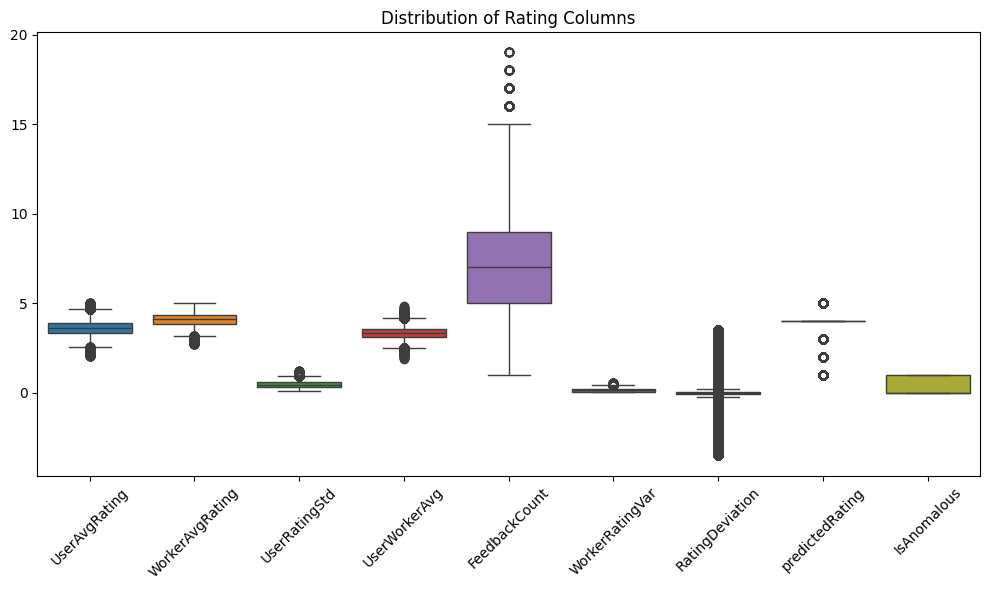

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[df.columns])
plt.title("Distribution of Rating Columns")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### There Is Outlier But it isn't harmful because our data about (Anomaly) it is normal to find noise and outlier

<hr style="border: 2px solid red; width: 80%;">
<h1 style="text-align:center; font-family: 'Arial', sans-serif; color : black;">
3 - Visualization & Analysis
</h1>
<hr style="border: 2px solid red; width: 80%;">

# Univarate Analysis

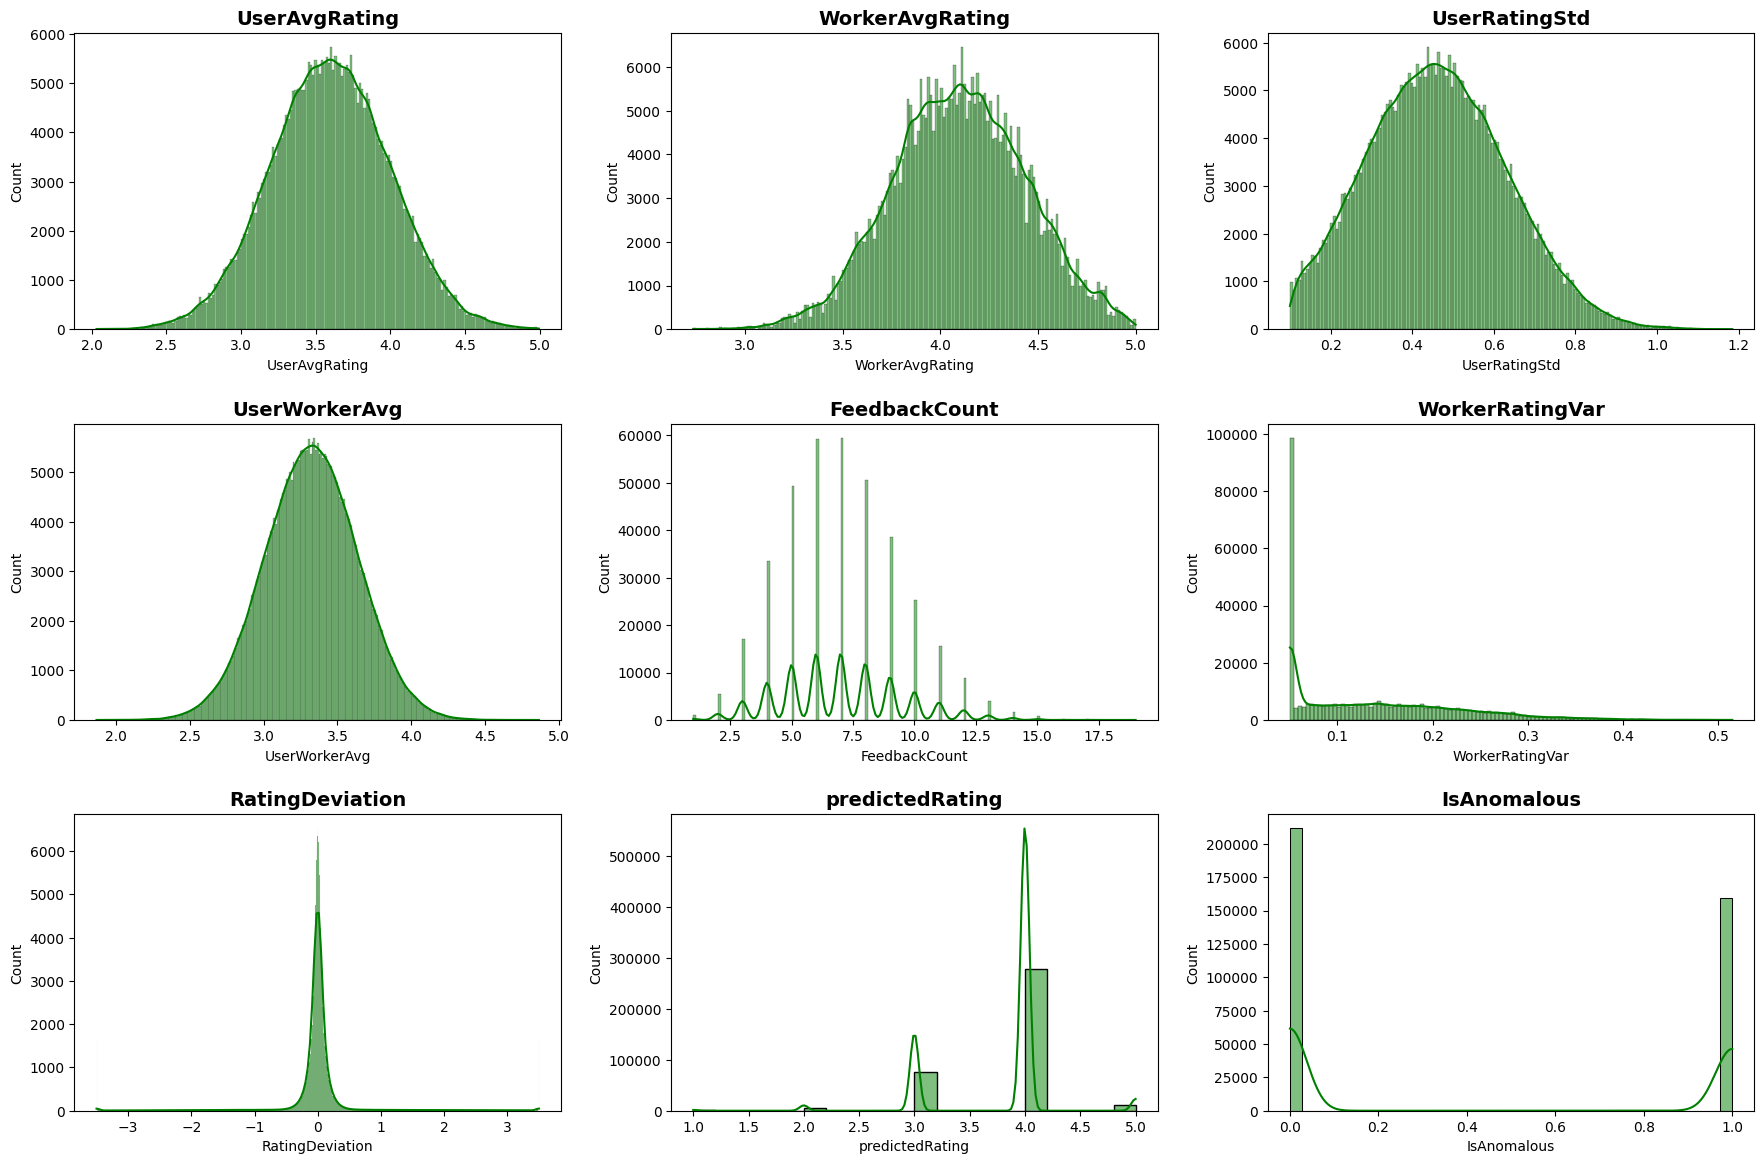

In [20]:
plt.figure(figsize=(18, 12))   
i=1
for  col in df.columns:
    plt.subplot(3, 3, i)

    sns.histplot(df[col], kde=True , color='green')
    
    plt.title(col, fontsize=14, fontweight='bold') 
    plt.yticks(fontsize=10)
    i+=1

plt.tight_layout(pad=2.0) 
plt.show()


# Bi Virate Analysis

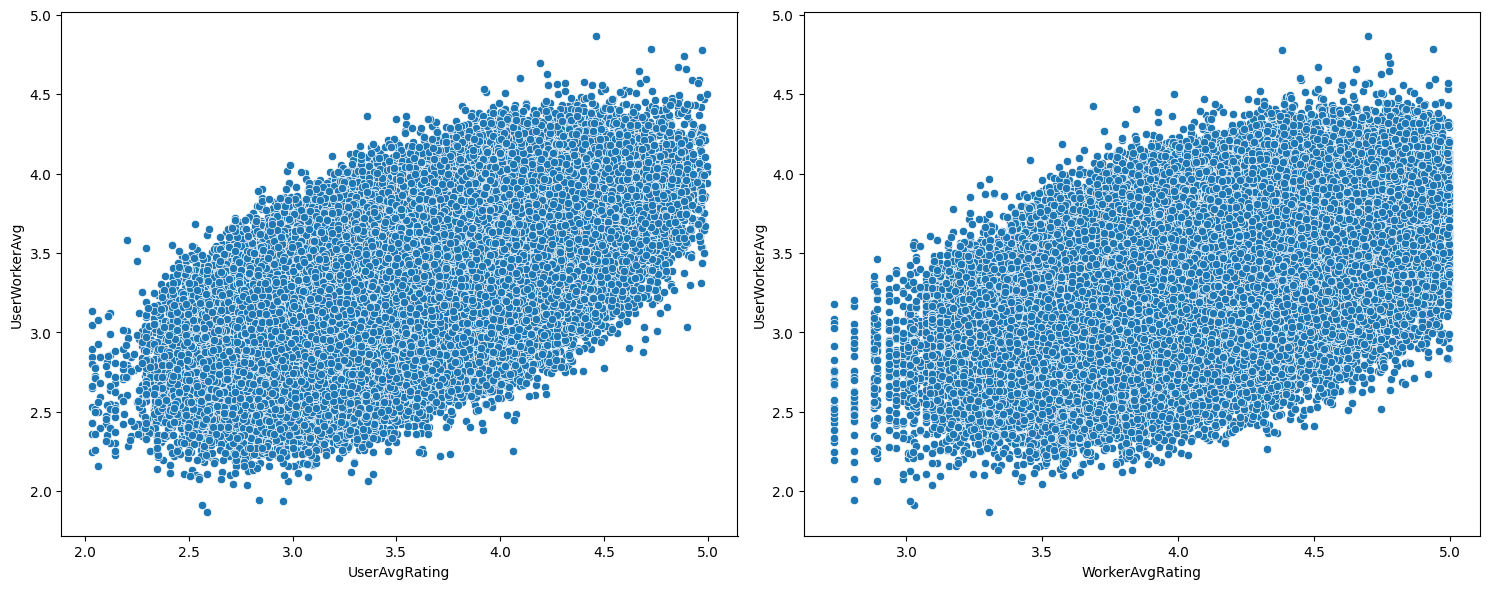

In [21]:
# UserWorkerAvg ×  ( WorkerAvgRating and UserAvgRating )
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
sns.scatterplot(x='UserAvgRating', y='UserWorkerAvg', data=df, palette='Set2')

plt.subplot(1,2,2)
sns.scatterplot(x='WorkerAvgRating', y='UserWorkerAvg', data=df, palette='Set1')
plt.tight_layout()
plt.show()


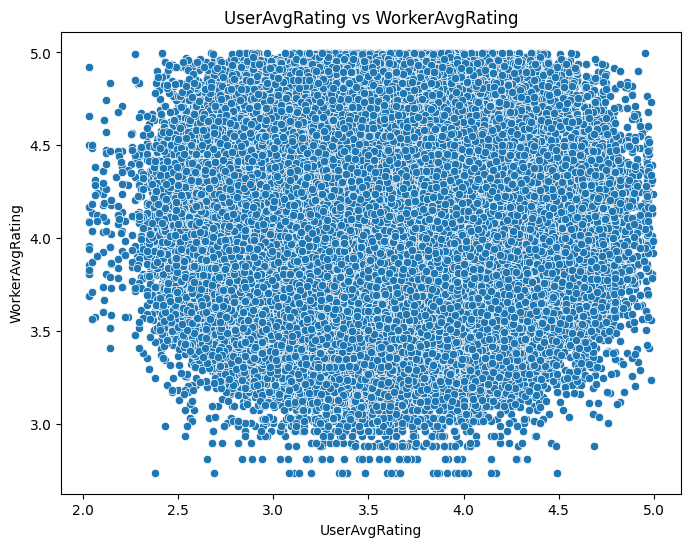

In [22]:
# useravgrating × workeravg
plt.figure(figsize=(8,6))
sns.scatterplot(x='UserAvgRating', y='WorkerAvgRating', data=df, palette='Set4')
plt.title('UserAvgRating vs WorkerAvgRating')
plt.show()


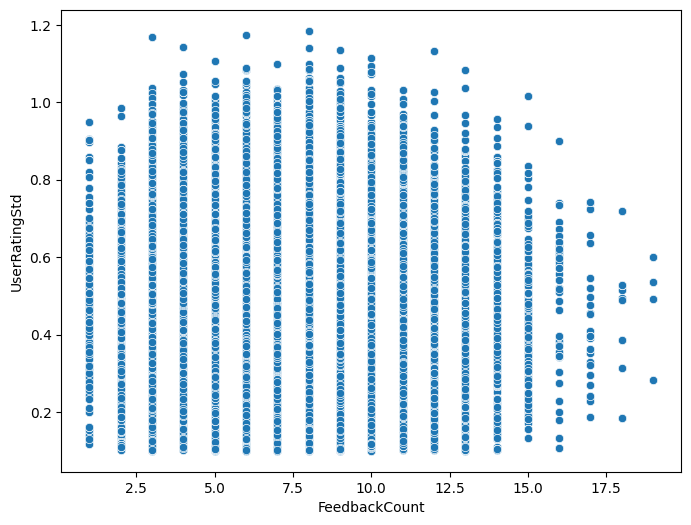

In [23]:
#FeedbackCount × UserRatingStd
plt.figure(figsize=(8,6))
sns.scatterplot(x='FeedbackCount', y='UserRatingStd', data=df, palette='Set3')
plt.show()  

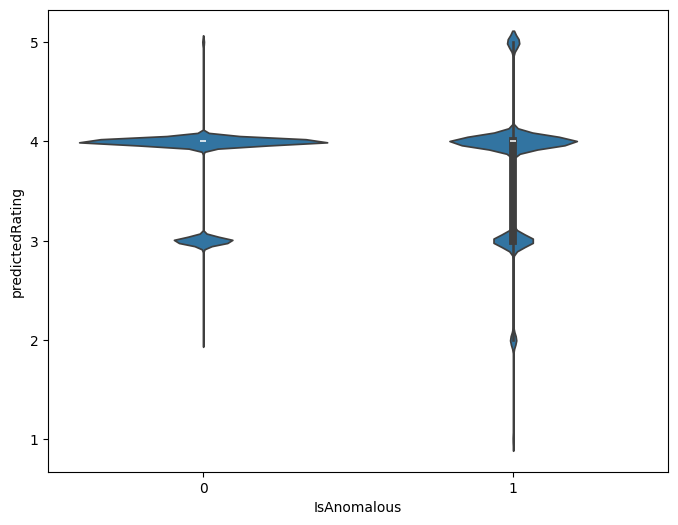

In [24]:
#predictedRating × IsAnomalous
plt.figure(figsize=(8,6))
sns.violinplot(x='IsAnomalous', y= 'predictedRating', data=df)
plt.show()

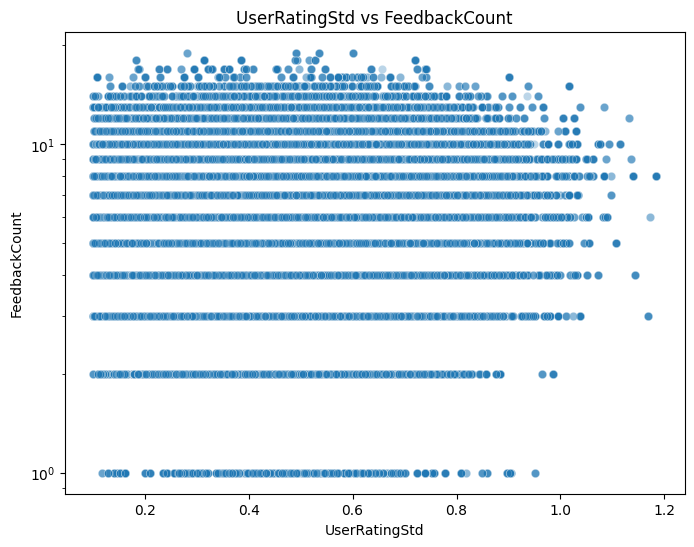

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='UserRatingStd',
    y='FeedbackCount',
    alpha=0.3
)

plt.yscale('log')
plt.title('UserRatingStd vs FeedbackCount')
plt.show()


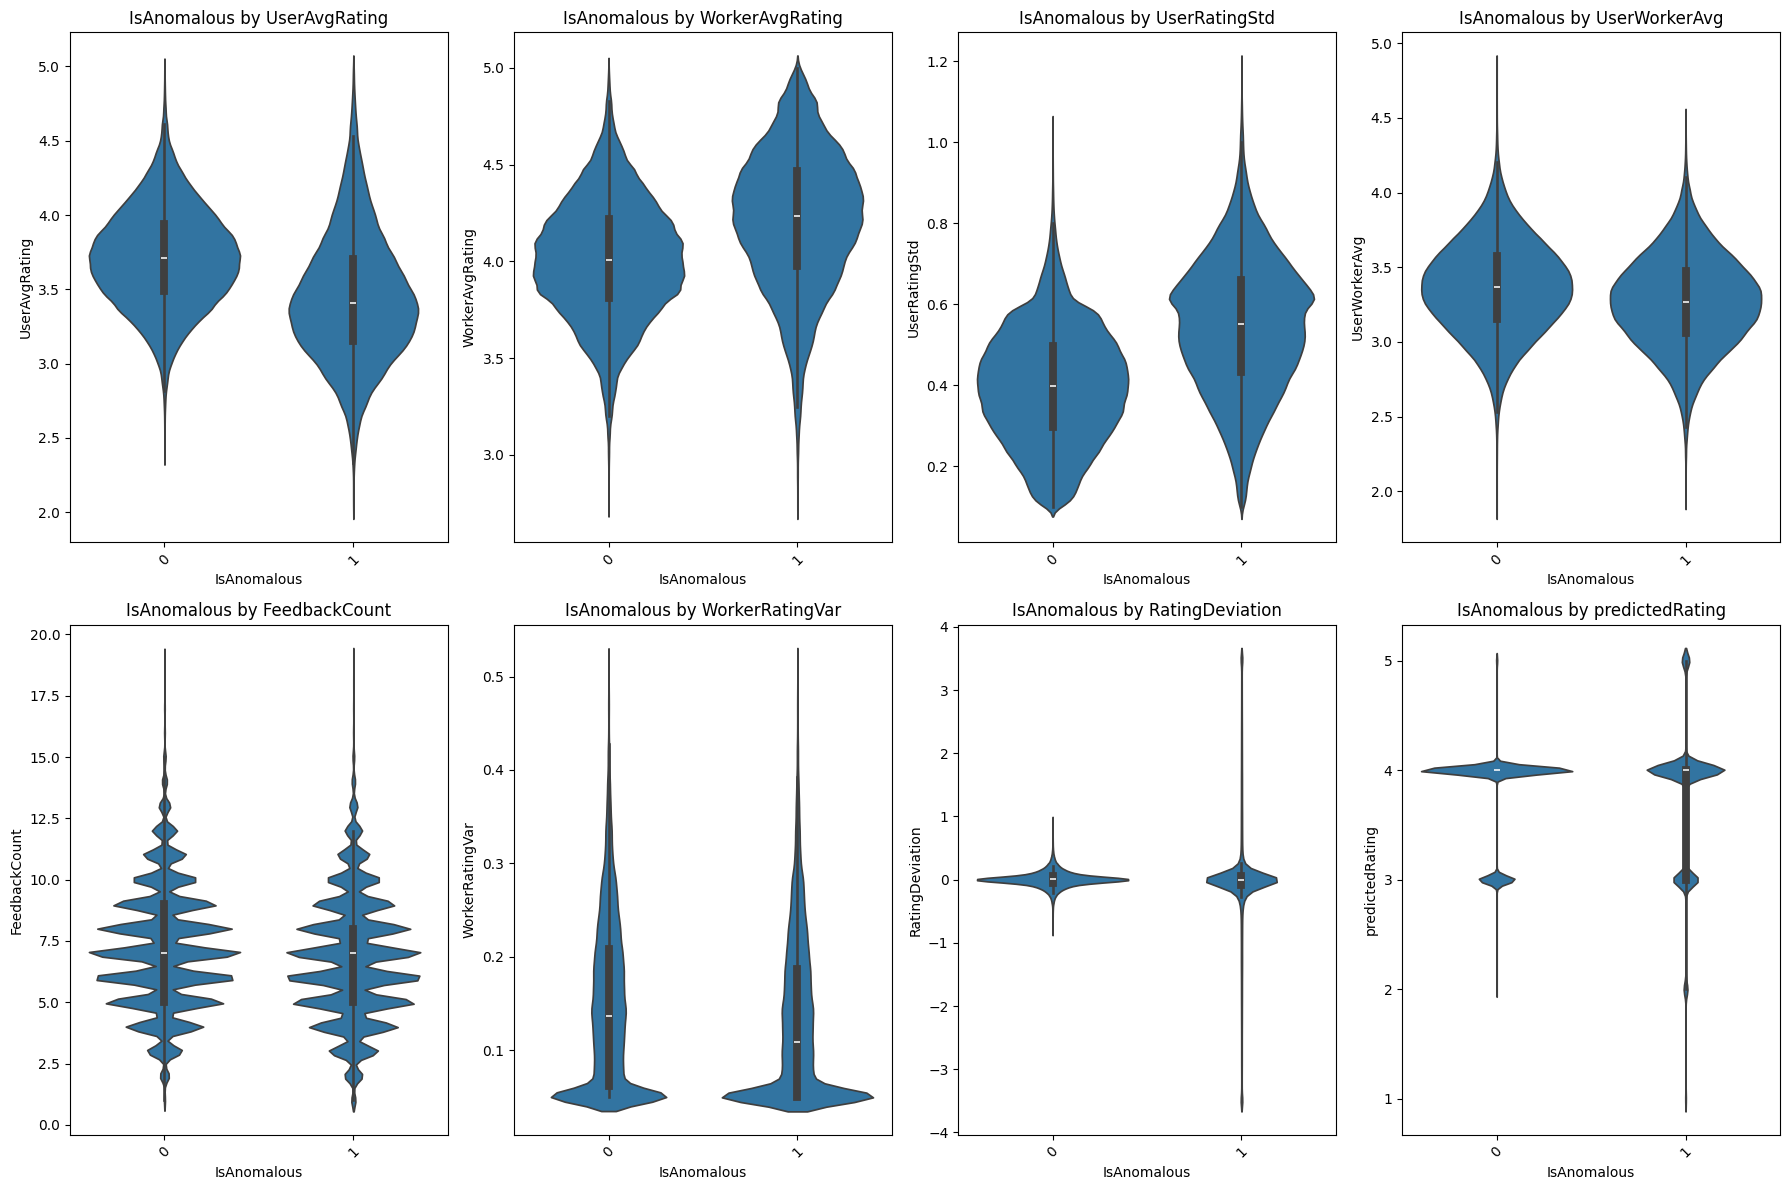

In [26]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(Rating_features, 1):
    plt.subplot(2, 4, i)
    sns.violinplot(data=df, x='IsAnomalous', y=col)
    plt.xticks(rotation=45)
    plt.title(f'IsAnomalous by {col}')
plt.tight_layout()
plt.show()

#  MultiVirate Analysis

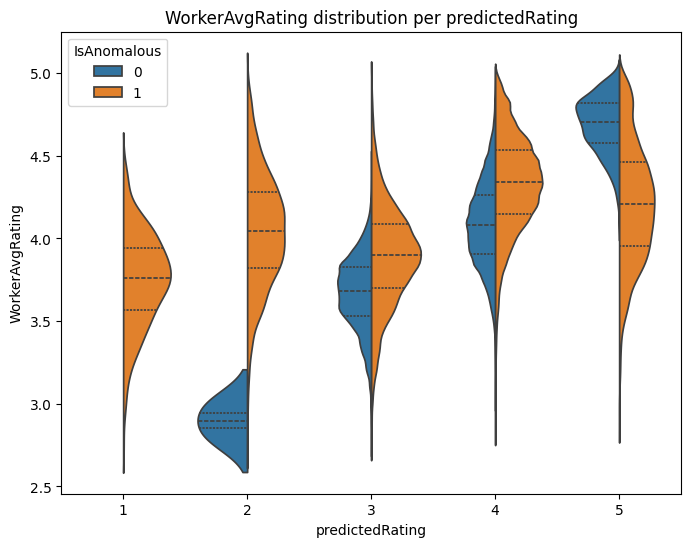

In [27]:
plt.figure(figsize=(8, 6))
sns.violinplot(
    x='predictedRating',
    y='WorkerAvgRating',
    hue = 'IsAnomalous',
    split=True,
    data=df,
    inner='quartile'
)
plt.title('WorkerAvgRating distribution per predictedRating')
plt.show()


#### As We Show Not All Predicet rates are Present in WorkerAvgRating (Some Anamolies make This )


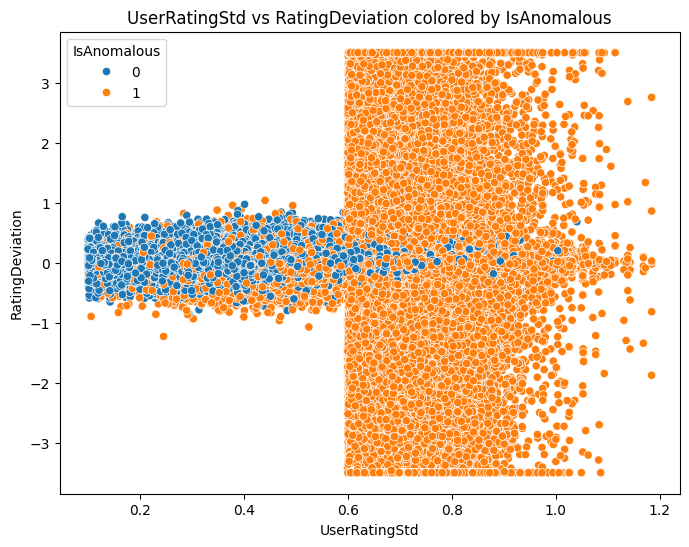

In [28]:
#UserRatingStd × RatingDeviation × IsAnomalous
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,    
    x='UserRatingStd',
    y='RatingDeviation',
    hue='IsAnomalous',
)
plt.title('UserRatingStd vs RatingDeviation colored by IsAnomalous')
plt.show()

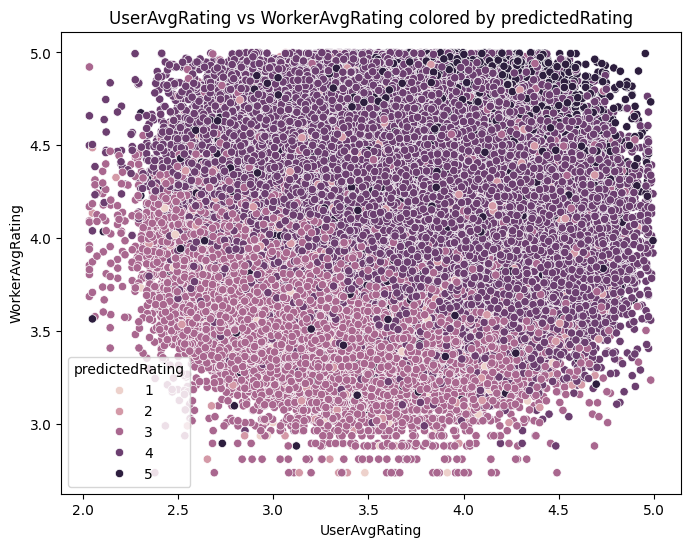

In [29]:
#UserAvgRating × WorkerAvgRating × predictedRating
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='UserAvgRating',
    y='WorkerAvgRating',
    hue='predictedRating',
)
plt.title('UserAvgRating vs WorkerAvgRating colored by predictedRating')
plt.show()


In [30]:
df.corr()

,UserAvgRating,WorkerAvgRating,UserRatingStd,UserWorkerAvg,FeedbackCount,WorkerRatingVar,RatingDeviation,predictedRating,IsAnomalous
UserAvgRating,1.000000,0.000416,-0.002654,0.571388,-0.002246,0.001164,-0.000280,0.227219,-0.334815
WorkerAvgRating,0.000416,1.000000,0.001878,0.490441,-0.002265,-0.410098,0.001034,0.420691,0.290594
UserRatingStd,-0.002654,0.001878,1.000000,-0.163096,-0.000598,-0.000614,0.003280,-0.065204,0.433083
UserWorkerAvg,0.571388,0.490441,-0.163096,1.000000,-0.004187,-0.200373,-0.000985,0.428984,-0.154210
FeedbackCount,-0.002246,-0.002265,-0.000598,-0.004187,1.000000,0.003150,-0.000769,-0.001853,-0.085520
WorkerRatingVar,0.001164,-0.410098,-0.000614,-0.200373,0.003150,1.000000,0.000319,-0.185442,-0.095612
RatingDeviation,-0.000280,0.001034,0.003280,-0.000985,-0.000769,0.000319,1.000000,0.623878,-0.012288
predictedRating,0.227219,0.420691,-0.065204,0.428984,-0.001853,-0.185442,0.623878,1.000000,-0.049123
IsAnomalous,-0.334815,0.290594,0.433083,-0.154210,-0.085520,-0.095612,-0.012288,-0.049123,1.000000


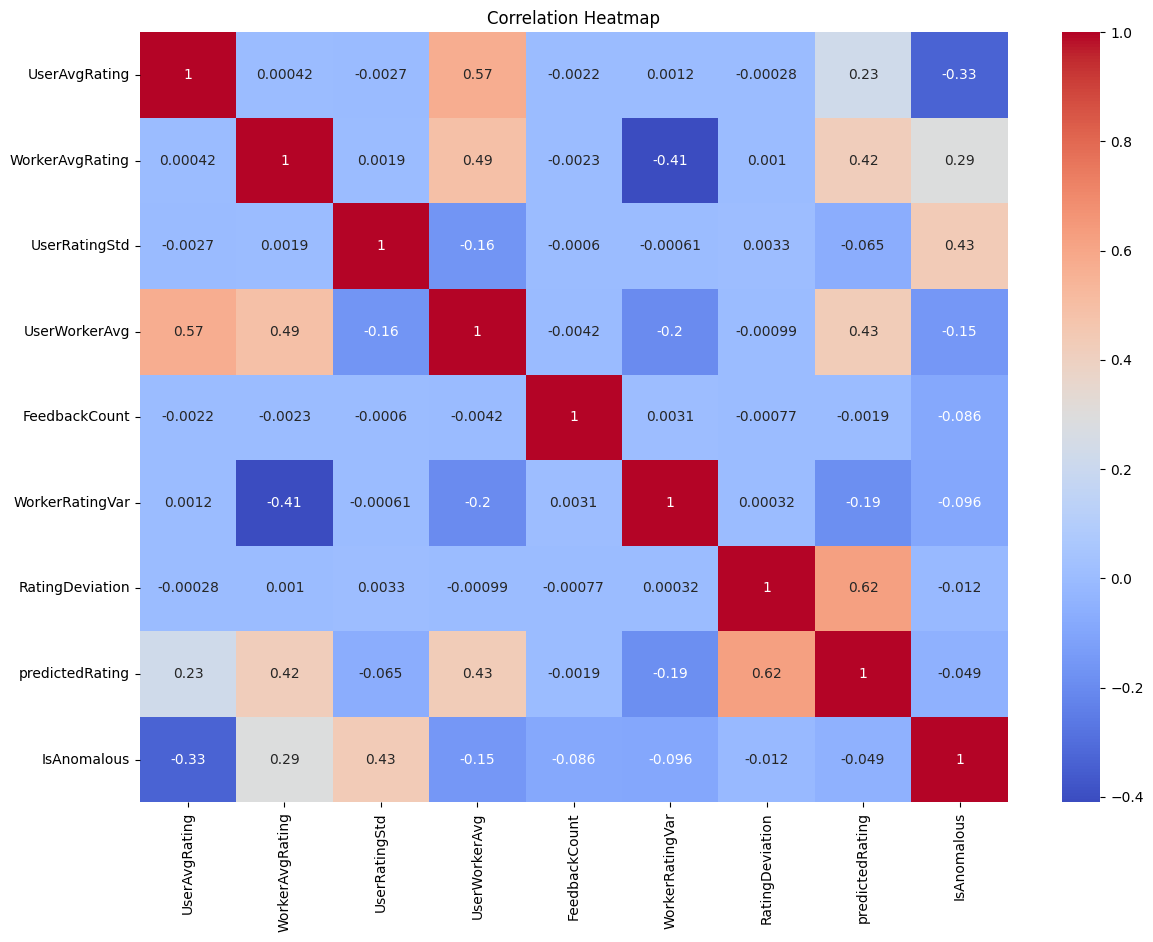

In [31]:
plt.figure(figsize=(14,10))
sns.heatmap(df[df.columns].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [32]:
df[df.columns].corr()['IsAnomalous'].sort_values(ascending=False)


IsAnomalous        1.000000
UserRatingStd      0.433083
WorkerAvgRating    0.290594
RatingDeviation   -0.012288
predictedRating   -0.049123
FeedbackCount     -0.085520
WorkerRatingVar   -0.095612
UserWorkerAvg     -0.154210
UserAvgRating     -0.334815
Name: IsAnomalous, dtype: float64

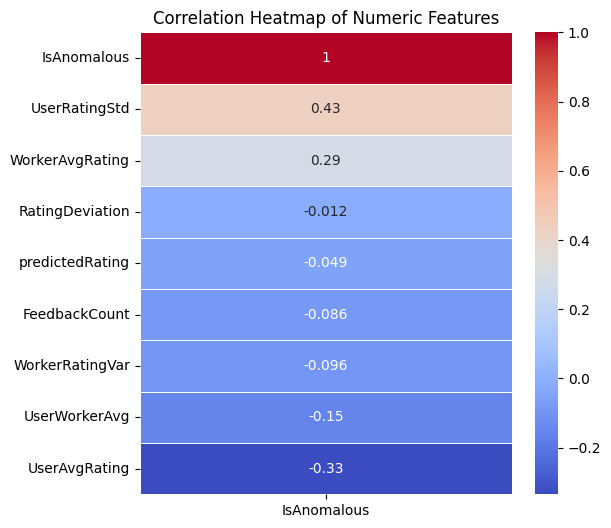

In [33]:
plt.figure(figsize=(6, 6))
corr = df[df.columns].corr()
corr_with_rating = corr['IsAnomalous'].sort_values(ascending=False).to_frame()

sns.heatmap(corr_with_rating, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

<hr style="border: 2px solid red; width: 80%;">
<h1 style="text-align:center; font-family: 'Arial', sans-serif; color : black;">
3 - Preprocessing 
</h1>
<hr style="border: 2px solid red; width: 80%;">

# Spiliting

In [34]:
X = df.drop(columns=['IsAnomalous'])
y = df['IsAnomalous']

In [35]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

<hr style="border: 2px solid red; width: 80%;">
<h1 style="text-align:center; font-family: 'Arial', sans-serif; color : black;">
4 - Models & Evaluation
</h1>
<hr style="border: 2px solid red; width: 80%;">

In [36]:
cv = StratifiedKFold(n_splits=5,
                     shuffle=True,
                     random_state=42)

In [37]:
models_and_grids = {

    "XGBoost": {
        "pipeline": Pipeline([
            ("model", XGBClassifier(
                eval_metric="logloss",
                random_state=42,
            ))
        ]),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [3, 6]
        }
    },

    "LightGBM": {
        "pipeline": Pipeline([
            ("model", LGBMClassifier(
                random_state=42,
            ))
        ]),
        "params": {
            "model__n_estimators": [100, 200],
            "model__num_leaves": [31, 50]
        }
    },

    "CatBoost": {
        "pipeline": Pipeline([
            ("model", CatBoostClassifier(
                random_state=42,
                verbose=0
            ))
        ]),
        "params": {
            "model__iterations": [100, 200],
            "model__depth": [4, 6]
        }
    },

    "RandomForest": {
        "pipeline": Pipeline([
            ("model", RandomForestClassifier(
                random_state=42,
            ))
        ]),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 10]
        }
    },

    "ExtraTrees": {
        "pipeline": Pipeline([
            ("model", ExtraTreesClassifier(
                random_state=42,
            ))
        ]),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 10]
        }
    },

    "VotingClassifier": {
        "pipeline": Pipeline([
            ("model", VotingClassifier(
                estimators=[
                    ("cat", CatBoostClassifier(
                        random_state=42,
                        verbose=False
                    )),
                    ("rf", RandomForestClassifier(random_state=42, n_jobs=-1)),
                    ("xgb", XGBClassifier(
                        eval_metric="logloss",
                        random_state=42,
                    ))
                ],
                voting="hard"
            ))
        ]),
        "params": None
    }
}


In [119]:
def Training(models_and_grids, X_train, y_train, X_val, y_val, cv ):

    results = [] 
    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1"
    }
    
    for name, config in models_and_grids.items():

        print(f"\nTraining Model: {name}")
        print("=" * 60)

        
       # Train All Models
        if config["params"] is None:
            model = config["pipeline"]
            model.fit(X_train, y_train)
            best_params = "No GridSearch"
    
        else:
            grid = GridSearchCV(
                estimator=config["pipeline"],
                param_grid=config["params"],
                scoring=scoring,
                refit="f1",
                cv=cv,
                n_jobs=2,
                verbose=False
            )

            grid.fit(X_train, y_train)
            model = grid.best_estimator_
            best_params = grid.best_params_

        
        # Validation
        y_pred = model.predict(X_val)
        y_train_pred = model.predict(X_train)

        
        # Metrics
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred)
        rec = recall_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        train_acc = accuracy_score(y_train, y_train_pred)

        results.append({
                "Model": name,
                "Val_Accuracy": acc,
                "Train_Accuracy":train_acc,
                "Precision": prec,
                "Recall": rec,
                "F1 Score": f1,
                "Best Params": best_params,
                "Estimator": model
            })

        print(f"{name} Acc : {acc}")
        # Classification Report
        print("\nClassification Report:")
        print(classification_report(y_val, y_pred))

        # Confusion Matrix
        cm = confusion_matrix(y_val, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap=plt.cm.Blues)
        plt.title(f"Confusion Matrix - {name}")
        plt.show()
            
    return results



Training Model: XGBoost
XGBoost Acc : 0.9498759483657545

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96     31718
           1       0.96      0.93      0.94     23904

    accuracy                           0.95     55622
   macro avg       0.95      0.95      0.95     55622
weighted avg       0.95      0.95      0.95     55622



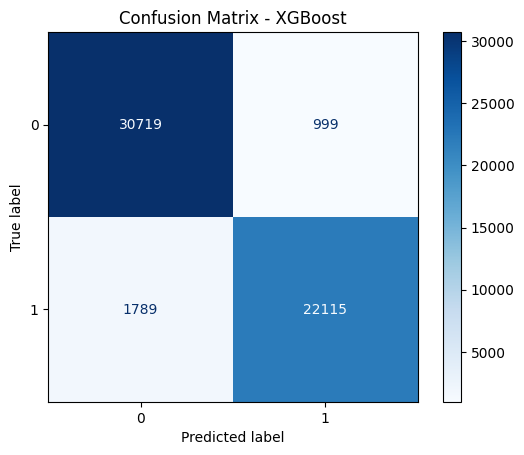


Training Model: LightGBM
[LightGBM] [Info] Number of positive: 111555, number of negative: 148013
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002883 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1556
[LightGBM] [Info] Number of data points in the train set: 259568, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.429772 -> initscore=-0.282782
[LightGBM] [Info] Start training from score -0.282782
LightGBM Acc : 0.9499478623566214

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96     31718
           1       0.96      0.92      0.94     23904

    accuracy                           0.95     55622
   macro avg       0.95      0.95      0.95     55622
weighted avg       0.95      0.95      0.95     55622



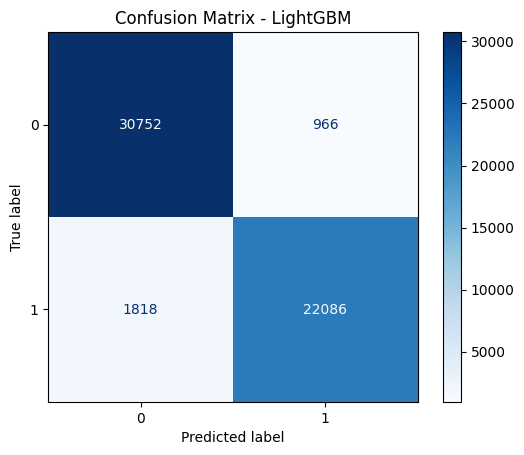


Training Model: CatBoost
CatBoost Acc : 0.9485275610369998

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96     31718
           1       0.96      0.92      0.94     23904

    accuracy                           0.95     55622
   macro avg       0.95      0.95      0.95     55622
weighted avg       0.95      0.95      0.95     55622



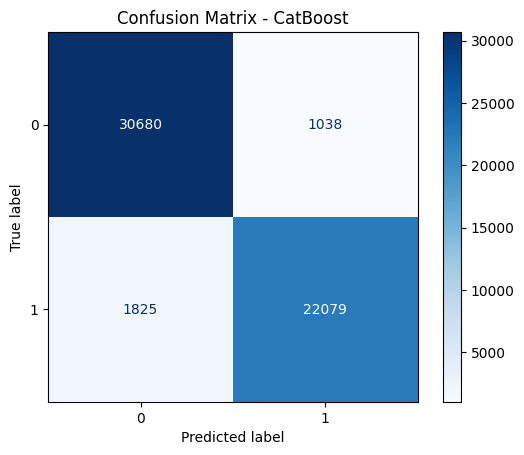


Training Model: RandomForest
[LightGBM] [Info] Number of positive: 89244, number of negative: 118410
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004109 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1556
[LightGBM] [Info] Number of data points in the train set: 207654, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.429773 -> initscore=-0.282779
[LightGBM] [Info] Start training from score -0.282779
[LightGBM] [Info] Number of positive: 89244, number of negative: 118410
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004149 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1556
[LightGBM] [Info] Number of data points in the train set: 207654, number of use

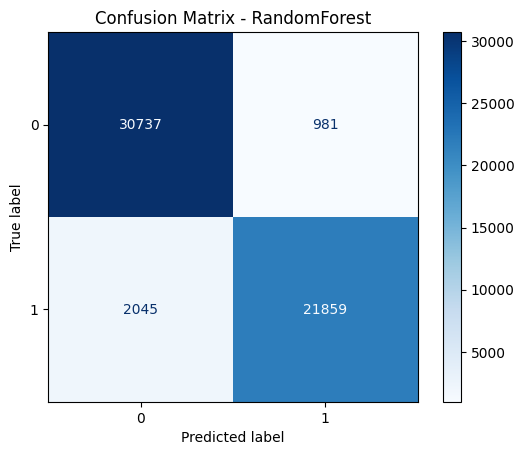


Training Model: ExtraTrees
ExtraTrees Acc : 0.9448599475027867

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     31718
           1       0.96      0.91      0.93     23904

    accuracy                           0.94     55622
   macro avg       0.95      0.94      0.94     55622
weighted avg       0.95      0.94      0.94     55622



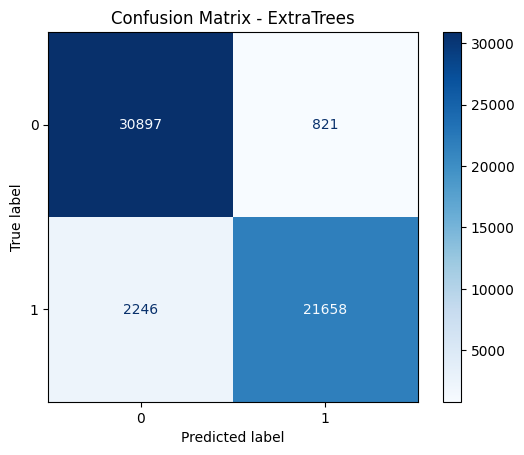


Training Model: VotingClassifier
VotingClassifier Acc : 0.9513681636762432

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96     31718
           1       0.96      0.92      0.94     23904

    accuracy                           0.95     55622
   macro avg       0.95      0.95      0.95     55622
weighted avg       0.95      0.95      0.95     55622



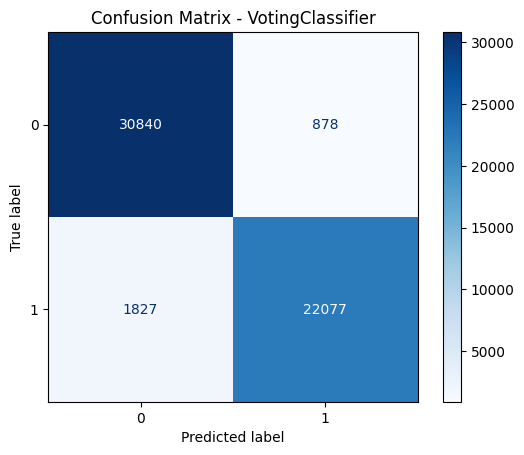

In [120]:
results = Training(models_and_grids, X_train, y_train, X_val, y_val, cv)
results_df = pd.DataFrame(results)


In [121]:
results_df.sort_values(by="F1 Score", ascending=False)

,Model,Val_Accuracy,Train_Accuracy,Precision,Recall,F1 Score,Best Params,Estimator
5,VotingClassifier,0.951368,0.965235,0.961751,0.923569,0.942274,No GridSearch,"(VotingClassifier(estimators=[('cat',\n ..."
1,LightGBM,0.949948,0.957090,0.958095,0.923946,0.940710,"{'model__n_estimators': 200, 'model__num_leave...","(LGBMClassifier(n_estimators=200, num_leaves=5..."
0,XGBoost,0.949876,0.962688,0.956779,0.925159,0.940704,"{'model__max_depth': 6, 'model__n_estimators':...","(XGBClassifier(base_score=None, booster=None, ..."
2,CatBoost,0.948528,0.955992,0.955098,0.923653,0.939112,"{'model__depth': 6, 'model__iterations': 200}",(<catboost.core.CatBoostClassifier object at 0...
3,RandomForest,0.945597,1.000000,0.957049,0.914449,0.935264,"{'model__max_depth': None, 'model__n_estimator...","((DecisionTreeClassifier(max_features='sqrt', ..."
4,ExtraTrees,0.944860,1.000000,0.963477,0.906041,0.933877,"{'model__max_depth': None, 'model__n_estimator...",((ExtraTreeClassifier(random_state=1608637542)...


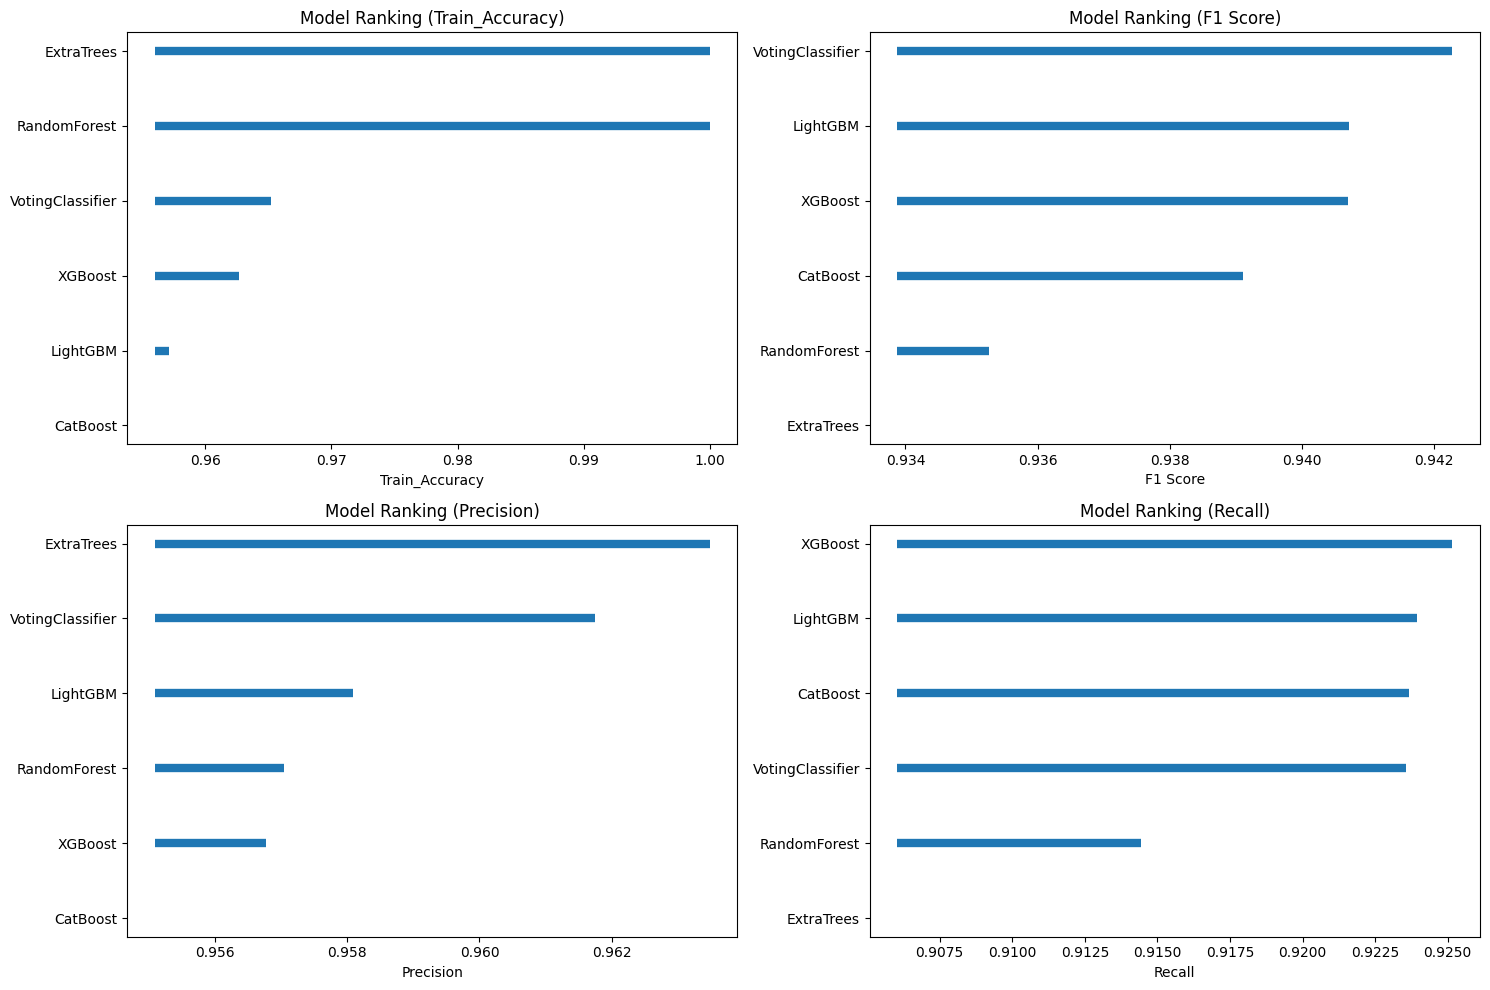

In [122]:
import matplotlib as mpl
plt.figure(figsize=(15, 10))

def Draw_Compare(i , x  , y , results_df , name):
    
    plt.subplot(2,2,i)
    sorted_df = results_df.sort_values(y)

    plt.hlines(
        y=sorted_df["Model"],
        xmin=sorted_df[y].min(),
        xmax=sorted_df[y],
        linewidth=6
    )
    
    plt.xlabel(f"{name}")
    plt.title(f"Model Ranking ({name})")


Draw_Compare(1, 'Model'  , "Train_Accuracy" , results_df , 'Train_Accuracy')
Draw_Compare(2, 'Model' , "F1 Score", results_df , 'F1 Score')
Draw_Compare(3, 'Model' , "Precision", results_df , 'Precision')
Draw_Compare(4, 'Model' , "Recall", results_df , 'Recall')

plt.tight_layout()
plt.show()



### Best Model 

In [123]:
sorted_df = results_df.sort_values(by=['Recall' , "F1 Score",'Precision'], ascending=False)
sorted_df

,Model,Val_Accuracy,Train_Accuracy,Precision,Recall,F1 Score,Best Params,Estimator
0,XGBoost,0.949876,0.962688,0.956779,0.925159,0.940704,"{'model__max_depth': 6, 'model__n_estimators':...","(XGBClassifier(base_score=None, booster=None, ..."
1,LightGBM,0.949948,0.957090,0.958095,0.923946,0.940710,"{'model__n_estimators': 200, 'model__num_leave...","(LGBMClassifier(n_estimators=200, num_leaves=5..."
2,CatBoost,0.948528,0.955992,0.955098,0.923653,0.939112,"{'model__depth': 6, 'model__iterations': 200}",(<catboost.core.CatBoostClassifier object at 0...
5,VotingClassifier,0.951368,0.965235,0.961751,0.923569,0.942274,No GridSearch,"(VotingClassifier(estimators=[('cat',\n ..."
3,RandomForest,0.945597,1.000000,0.957049,0.914449,0.935264,"{'model__max_depth': None, 'model__n_estimator...","((DecisionTreeClassifier(max_features='sqrt', ..."
4,ExtraTrees,0.944860,1.000000,0.963477,0.906041,0.933877,"{'model__max_depth': None, 'model__n_estimator...",((ExtraTreeClassifier(random_state=1608637542)...


In [125]:
Final_model = sorted_df['Estimator'][0]
Final_model

Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [131]:
y_test_pred = Final_model.predict(X_test)


print(f"Test Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Test F1_Score : {f1_score(y_test, y_test_pred):.4f}")
print(f"Test Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Test Recall   : {recall_score(y_test, y_test_pred):.4f}")




Test Accuracy : 0.9496
Test F1_Score : 0.9404
Test Precision: 0.9557
Test Recall   : 0.9256



Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     31717
           1       0.96      0.93      0.94     23905

    accuracy                           0.95     55622
   macro avg       0.95      0.95      0.95     55622
weighted avg       0.95      0.95      0.95     55622



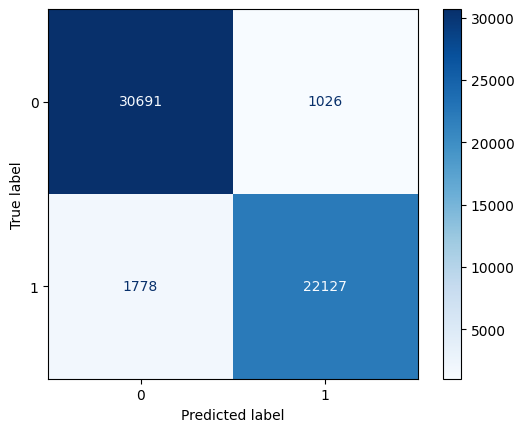

In [132]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

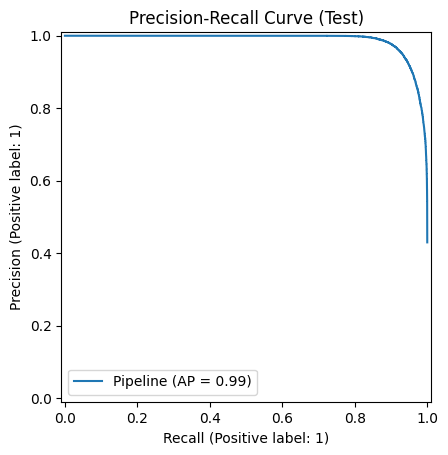

In [134]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    Final_model,
    X_test,
    y_test
)
plt.title("Precision-Recall Curve (Test)")
plt.show()


In [135]:
import joblib
joblib.dump(Final_model, "best_anomaly_model.pkl")


['best_anomaly_model.pkl']